# 📊 Exploratory Data Analysis on Netflix Dataset

## 📌 Business Understanding

The goal of this project is to analyze Netflix content data to uncover patterns, trends, and insights related to content distribution, growth, and audience targeting.  
This analysis helps understand how Netflix has evolved its content strategy over time.

## ❓ Key Business Questions

- What type of content dominates Netflix (Movies vs TV Shows)?
- Which countries contribute the most content?
- How has content production evolved over time?
- What ratings are most common, and what do they indicate about target audience?
- Which genres are most frequently produced?
- Are there noticeable trends in content growth?

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.style.use('ggplot')

In [2]:
import pandas as pd
df = pd.read_csv("C:/Users/Bhavana/OneDrive/Desktop/1/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


## 🔍 Data Understanding

- Dataset contains both categorical and numerical variables  
- Includes information like type, country, release year, rating, and genre  
- Majority of columns are categorical, suitable for trend analysis  

In [5]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [9]:
df['country'] = df['country'].fillna('Unknown')
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')

## 🧹 Data Cleaning

Missing values were found in columns such as country, director, cast, and rating.  
These were replaced with "Unknown" to maintain consistency and avoid data loss.

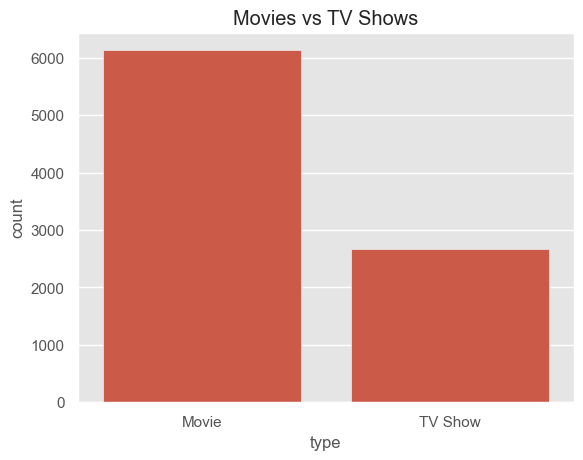

In [10]:
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()

Movies dominate the platform, indicating a stronger focus on film content.

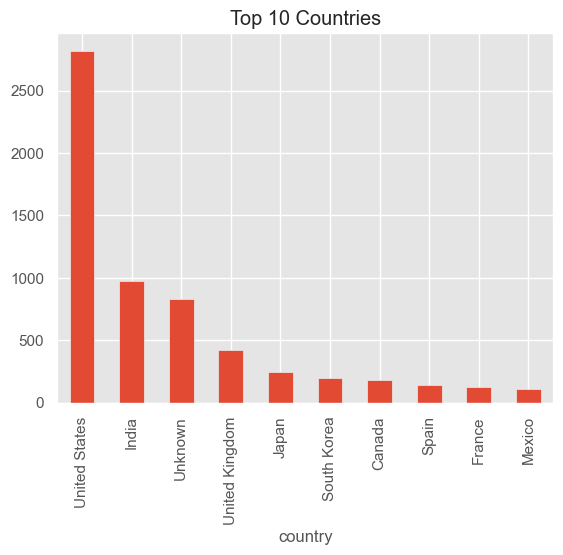

In [11]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries")
plt.show()

USA contributes the highest number of titles, showing its dominance in content production.

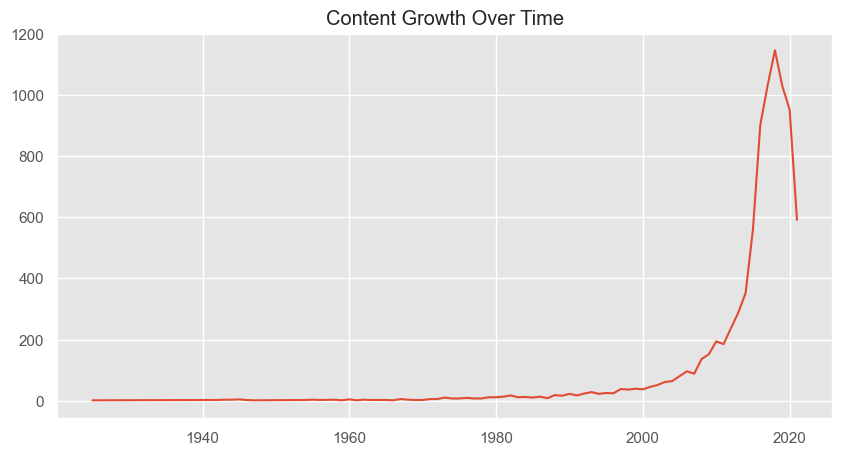

In [12]:
year_data = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(year_data)
plt.title("Content Growth Over Time")
plt.show()

Content production increased rapidly after 2015, suggesting aggressive expansion.

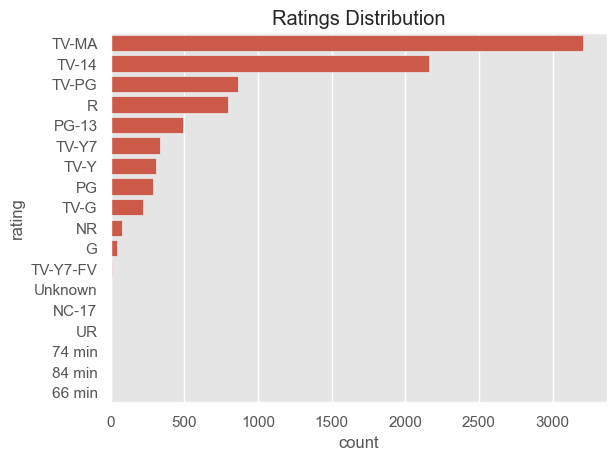

In [13]:
sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index)
plt.title("Ratings Distribution")
plt.show()

TV-MA and TV-14 are most common, indicating a focus on mature audiences.

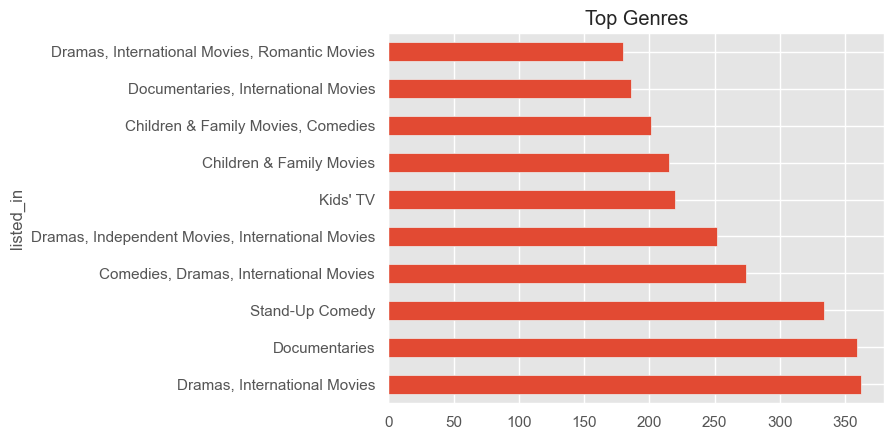

In [14]:
df['listed_in'].value_counts().head(10).plot(kind='barh')
plt.title("Top Genres")
plt.show()

Drama and International Movies genres dominate the platform.

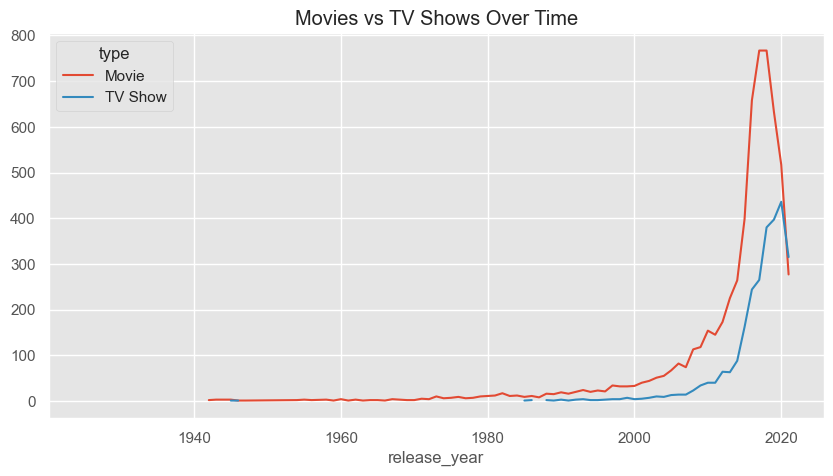

In [15]:
type_year = df.groupby(['release_year','type']).size().unstack()

type_year.plot(figsize=(10,5))
plt.title("Movies vs TV Shows Over Time")
plt.show()

Movies consistently dominate, but TV Shows have grown steadily in recent years.

## 🧪 Hypothesis Testing

Hypothesis 1: Netflix content has increased significantly in recent years.  
✔️ Supported by the upward trend in content after 2015.

Hypothesis 2: Movies are more common than TV Shows.  
✔️ Confirmed by countplot analysis.

## ⚠️ Data Issues

- Missing values in multiple columns  
- Imbalance between Movies and TV Shows  
- Some entries contain incomplete metadata

## 🏁 Conclusion

- Netflix has experienced rapid content growth, especially after 2015  
- Movies dominate the platform, though TV Shows are increasing  
- USA is the leading content producer  
- Content ratings suggest a focus on mature audiences  
- The platform shows a strong expansion and diversification strategy  